# Hybrid XGBoost + CNN Training V2

All modes use a **pretrained XGBoost** model loaded from `XGB_MODEL_PATH`.

| Mode | CNN input | Inference |
|---|---|---|
| `'prob_only'` | XGB prob (1 ch) | CNN output directly |
| `'prob_feat'` | features + XGB prob (C+1 ch) | CNN output directly |
| `'parallel'` | features only (C ch) | combine(CNN prob, XGB prob) |

For `patch_mode='full_padding'` the crop size is set automatically to `(min_H, min_W)`
across all samples; a random jitter shift is applied at dataset creation time.

## 1. Setup

In [1]:
import sys, os, socket
import torch
import importlib

# Two levels up: HybridTrainV2/ → NNsTorchV2/ → KIprojV2_Claude/ (project root)
sys.path.insert(0, os.path.dirname(os.path.dirname(os.getcwd())))

import NNsTorchV2
importlib.reload(NNsTorchV2)
import NNsTorchV2.HybridTrainV2 as htv2
importlib.reload(htv2)
#Pipeline1
#from NNsTorchV2.HybridTrainV2 import HybridTrainingManager, build_hybrid_model
#DATASET_N   = "V1"
#INVERT_MASK = True
#Pipeline2
from NNsTorchV2.HybridTrainV2.hybrid_manager_V2 import HybridTrainingManager
from NNsTorchV2.HybridTrainV2 import build_hybrid_model
DATASET_N   = "V2"
INVERT_MASK = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

def detect_system():
    h = socket.gethostname()
    if h.startswith('VDI0147'): return 'Thermo10'
    if h.startswith('NB'):      return 'Windows'
    return 'GPU'
SYSTEM = detect_system()
print(f'System: {SYSTEM}')

Device: cpu
System: GPU


## 2. Configuration

In [2]:
import os
# Load .env from project root (two levels up from notebook)
_env_path = os.path.join(os.getcwd(), '..', '..', '.env')
if os.path.exists(_env_path):
    with open(_env_path) as _f:
        for _line in _f:
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ.setdefault(_k.strip(), _v.strip())

# ── Mode ────────────────────────────────────────────────────────────────────
MODE      = 'nn_only'   # 'prob_only' | 'prob_feat' | 'parallel'| 'nn_only'
COMBINE   = 'mean'        # 'mean' | 'max'  — only used for 'parallel' mode-best prob or meansum
N_FILTERS = 32
INIT_W    = -10            #0 default#10 for 0.999, -10 for 0.001

# ── Data ─────────────────────────────────────────────────────────────────────
POWER_MODE  = '4kw_both'
SUBFOLDER   = 'Taris/Data_ML_V1_h5'
MASK_TYPE   = 'alternative'
MIN_MASK_AREA =0  # Filter out samples with very small masks for clearer visualization
MAX_LOC   = 5  # None = all
DATA_REGIME = 'postprocessed'
PPT_PHASES  = 'all'
PPT_AMPS    = 6
DIRS        = [1,5,6]#[1,5,6]#[0, 1, 2, 3, 4, 5, 6]   # [] = all
FROZE_W     = 5

# ── Patch / image size ────────────────────────────────────────────────────────
PATCH_MODE  = 'full_padding'  # 'full_padding' (auto min H/W) | 'patches' | 'full'
PATCH_SIZE  = (64, 64)      # used for 'patches'; overridden for 'full_padding'

# ── Training ──────────────────────────────────────────────────────────────────
MODEL_NAME = "unet"#'cnn_skip'
N_SPLITS   = 3
EPOCHS     = 15
PATIENCE   = 10
SHEDULE_NAME = 'cosine_warmup'  # 'cosine_warmup' | 'cosine' | 'step' | 'plateau' | 'onecycle' | 'none'
BATCH_SIZE = 4
LR         = 1e-3#3
WARMUP_EPOCHS = 3
LOSS_NAME  = 'distance_weighted_soft_iou_small_exclude'   # see NNsTorch/losses.py#distance_weighted_soft_iou
ALPHA      = 1.5        # Tversky FP penalty#0.75 focal#0.5 weighted iou
BETA       = 35        # Tversky FN penalty#2 focal#50 for distance penalty in weighted iou

# ── XGBoost ───────────────────────────────────────────────────────────────────
XGB_MODEL_PATH = os.environ.get('XGB_MODEL_PATH', '../../Trees/Trees_database/XGB_setV3[all]_md30minch30gam0.1_lr0.05_n300_normalized_scale2.joblib')

# ── MLflow ────────────────────────────────────────────────────────────────────
MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:////tmp/mlflow_experiments/mlflow.db')
print(f'MLflow UI: mlflow ui --backend-store-uri {MLFLOW_URI} --host 127.0.0.1 --port 5000')

MLflow UI: mlflow ui --backend-store-uri sqlite:////tmp/mlflow_experiments/mlflow.db --host 127.0.0.1 --port 5000


## 3. Initialise Manager

In [3]:
manager = HybridTrainingManager(
    model_name     = MODEL_NAME,
    sys            = SYSTEM,
    mode           = MODE,
    xgb_model_path = XGB_MODEL_PATH,
    power_mode     = POWER_MODE,
    subfolder_name = SUBFOLDER,
    patch_size     = PATCH_SIZE,
    patch_mode     = PATCH_MODE,
    initial_lr     = LR,
    loss_name      = LOSS_NAME,
    alpha          = ALPHA,
    beta           = BETA,
    mask_type      = MASK_TYPE,
    dirs           = DIRS,
    ppt_phases     = PPT_PHASES,
    ppt_amps       = PPT_AMPS,
    invert_mask    = INVERT_MASK,
    data_regime    = DATA_REGIME,
    combine        = COMBINE,
    mlflow_uri     = MLFLOW_URI,
    fusion_freeze_epochs=FROZE_W,
    save_chckpnt   = True,
    init_w         = INIT_W,
    dataset_n      = DATASET_N,
    max_locations  = MAX_LOC,  # Only load the specified location for visualization
    min_mask_area  = MIN_MASK_AREA,  # Filter out samples with very small masks for clearer visualization
    warmup_epochs  = WARMUP_EPOCHS,  # For cosine_warmup scheduler
    scheduler_name=SHEDULE_NAME,
)

# model_fn is called once per fold; n_raw_ch is stored by manager
def model_fn():
    return build_hybrid_model(MODE, manager.n_raw_ch, N_FILTERS,model_name=MODEL_NAME)

n_params = sum(p.numel() for p in model_fn().parameters())
print(f'Input shape : {manager.input_shape}')
print(f'Model params: {n_params:,}')

Device: cpu  |  mode: nn_only  |  patch_mode: full_padding
Output directory: unet
MLflow tracking: sqlite:////tmp/mlflow_experiments/mlflow.db
Discovered 15 samples
Auto patch_size (min H/W): [480, 445]
n_raw_ch=82  CNN input: (82, 480, 445)  (mode=nn_only)
Input shape : (82, 480, 445)
Model params: 489,921


## 4. Training

In [4]:
fold_metrics, avg = manager.run_kfold(
    model_fn,
    n_splits   = N_SPLITS,
    batch_size = BATCH_SIZE,
    epochs     = EPOCHS,
    patience   = PATIENCE,
)


Fold 1/3
TRAIN: 10 — Counter({1: 6, 0: 4})
VAL:   5 — Counter({1: 3, 0: 2})
  Ep   1: tr_loss=1.0302 va_loss=1.0228 prec=0.1327 rec=0.0909 iou=0.0570
  Ep   2: tr_loss=0.9597 va_loss=0.8799 prec=0.4308 rec=0.2096 iou=0.1660


/home/aaverin/miniforge3/envs/pytorch_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  Ep   3: tr_loss=0.8341 va_loss=0.7657 prec=0.7806 rec=0.2576 iou=0.2444
  Ep   4: tr_loss=0.7127 va_loss=0.7730 prec=0.8735 rec=0.2435 iou=0.2361
  Ep   5: tr_loss=0.6214 va_loss=0.7094 prec=0.8090 rec=0.3204 iou=0.2983
  Ep   6: tr_loss=0.5972 va_loss=0.5853 prec=0.5372 rec=0.7507 iou=0.4715
  Ep   7: tr_loss=0.5357 va_loss=0.5079 prec=0.6070 rec=0.7825 iou=0.5297
  Ep   8: tr_loss=0.5401 va_loss=0.4690 prec=0.6480 rec=0.7867 iou=0.5568
  Ep   9: tr_loss=0.5009 va_loss=0.5024 prec=0.6057 rec=0.7944 iou=0.5338
  Ep  10: tr_loss=0.4863 va_loss=0.4995 prec=0.6050 rec=0.8050 iou=0.5405
  Ep  11: tr_loss=0.4926 va_loss=0.4555 prec=0.6522 rec=0.7994 iou=0.5707
  Ep  12: tr_loss=0.4799 va_loss=0.4321 prec=0.6920 rec=0.7811 iou=0.5877
  Ep  13: tr_loss=0.4679 va_loss=0.4218 prec=0.7170 rec=0.7647 iou=0.5951
  Ep  14: tr_loss=0.4718 va_loss=0.4226 prec=0.7124 rec=0.7694 iou=0.5951
  Ep  15: tr_loss=0.4732 va_loss=0.4228 prec=0.7112 rec=0.7710 iou=0.5954
  Threshold tuning...
  Fold 1 final [

## 5. Results

In [6]:
names = ['Loss', 'Accuracy', 'Precision', 'Recall', 'IoU']
print(f'Mode: {MODE}  combine: {COMBINE}  |  Model: {manager.versioned_name}')
print('-' * 60)
for i, fm in enumerate(fold_metrics):
    print(f'Fold {i+1}: ' + '  '.join(f'{n}={v:.4f}' for n, v in zip(names, fm)))
print('=' * 60)
print('Average:')
for n, v in zip(names, avg):
    print(f'  {n:12s}: {v:.4f}')
print(f'\nCheckpoints: {manager.ckpt_dir}')

Mode: nn_only  combine: mean  |  Model: unet
------------------------------------------------------------
Fold 1: Loss=0.4218  Accuracy=0.9407  Precision=0.7205  Recall=0.7626  IoU=0.5964
Fold 2: Loss=0.5172  Accuracy=0.9307  Precision=0.7256  Recall=0.6485  IoU=0.5156
Fold 3: Loss=0.5784  Accuracy=0.9240  Precision=0.6186  Recall=0.6575  IoU=0.4562
Average:
  Loss        : 0.5058
  Accuracy    : 0.9318
  Precision   : 0.6882
  Recall      : 0.6895
  IoU         : 0.5227

Checkpoints: /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/checkpoints/unet/20260324-115341


## 6. Quick Inference Check (optional)

Load a saved fold model and visualise predictions on one sample.

/tmp/ipykernel_4056774/4198125421.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(ckpt_path, map_location=device)['model_state_dict'])


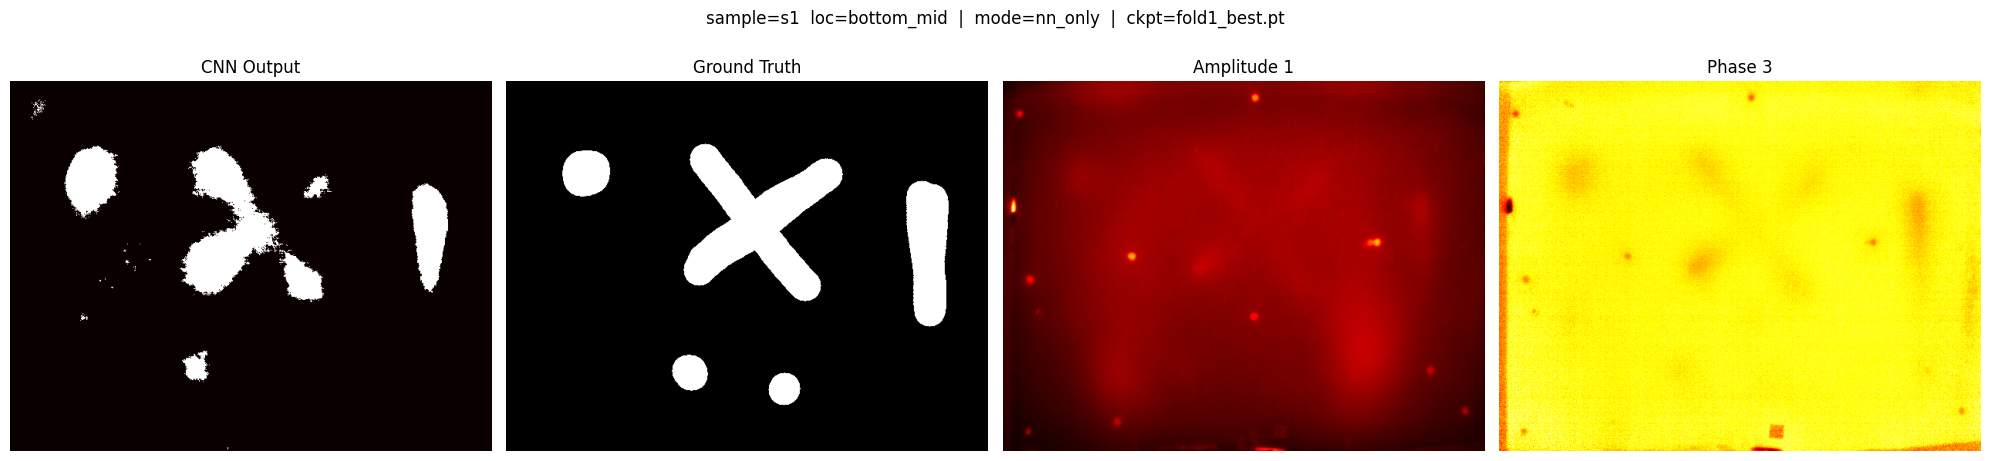

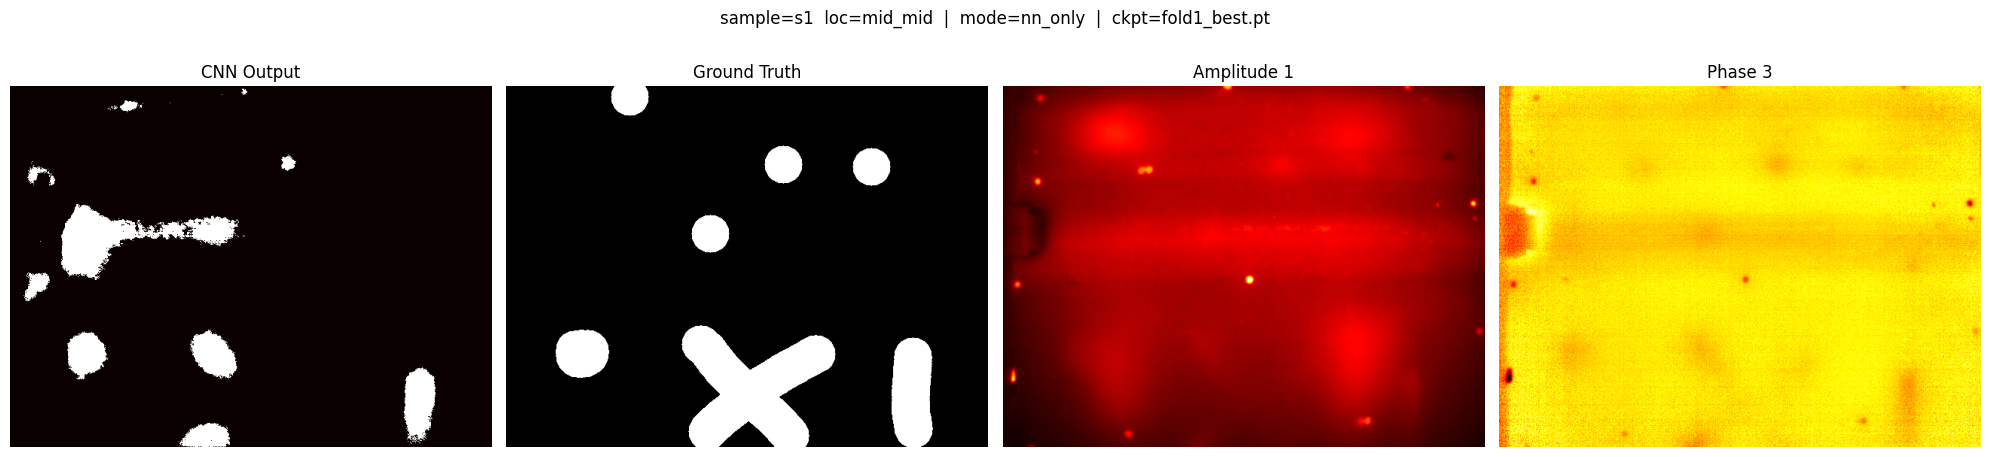

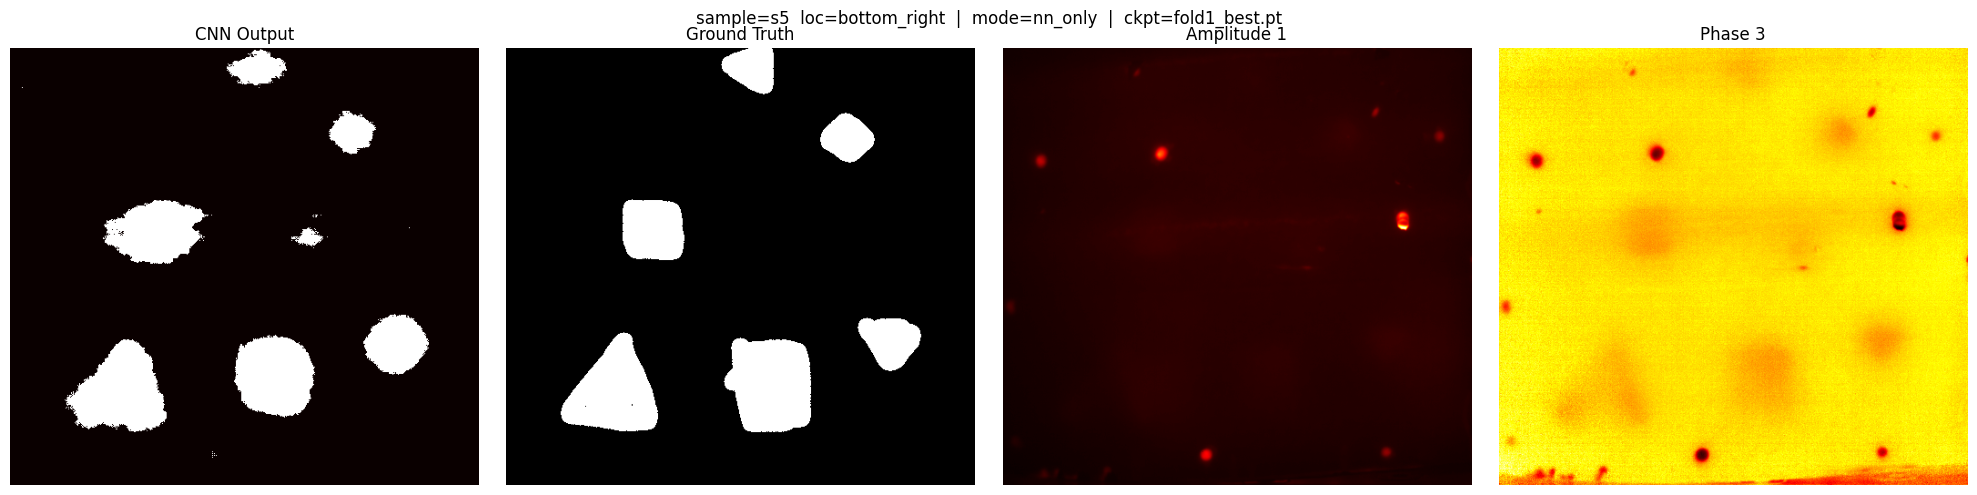

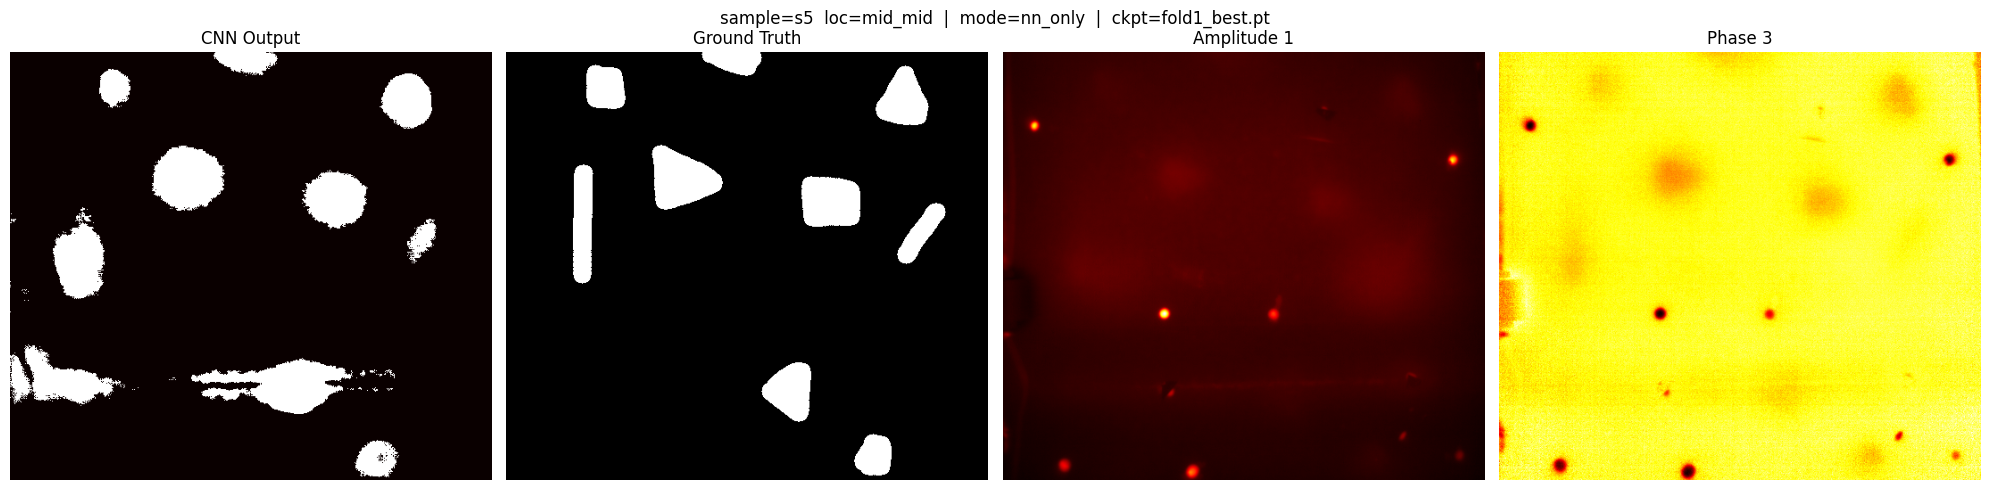

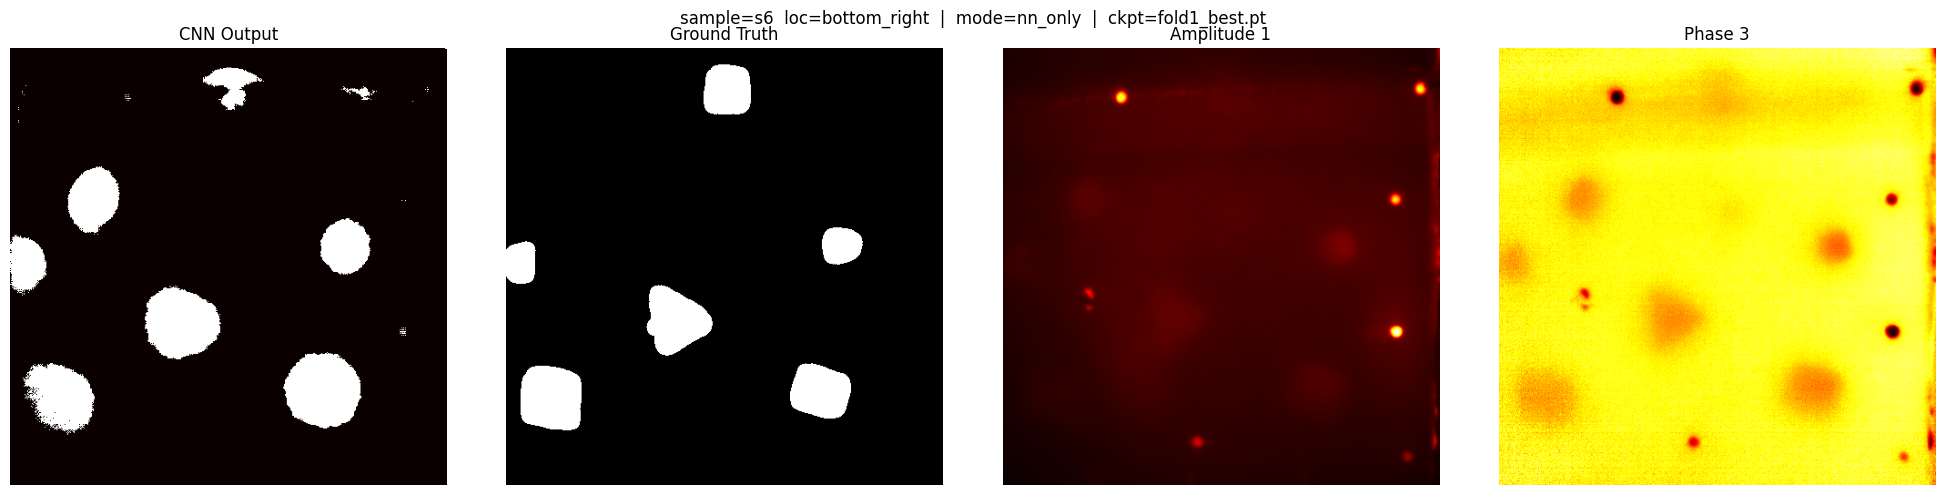

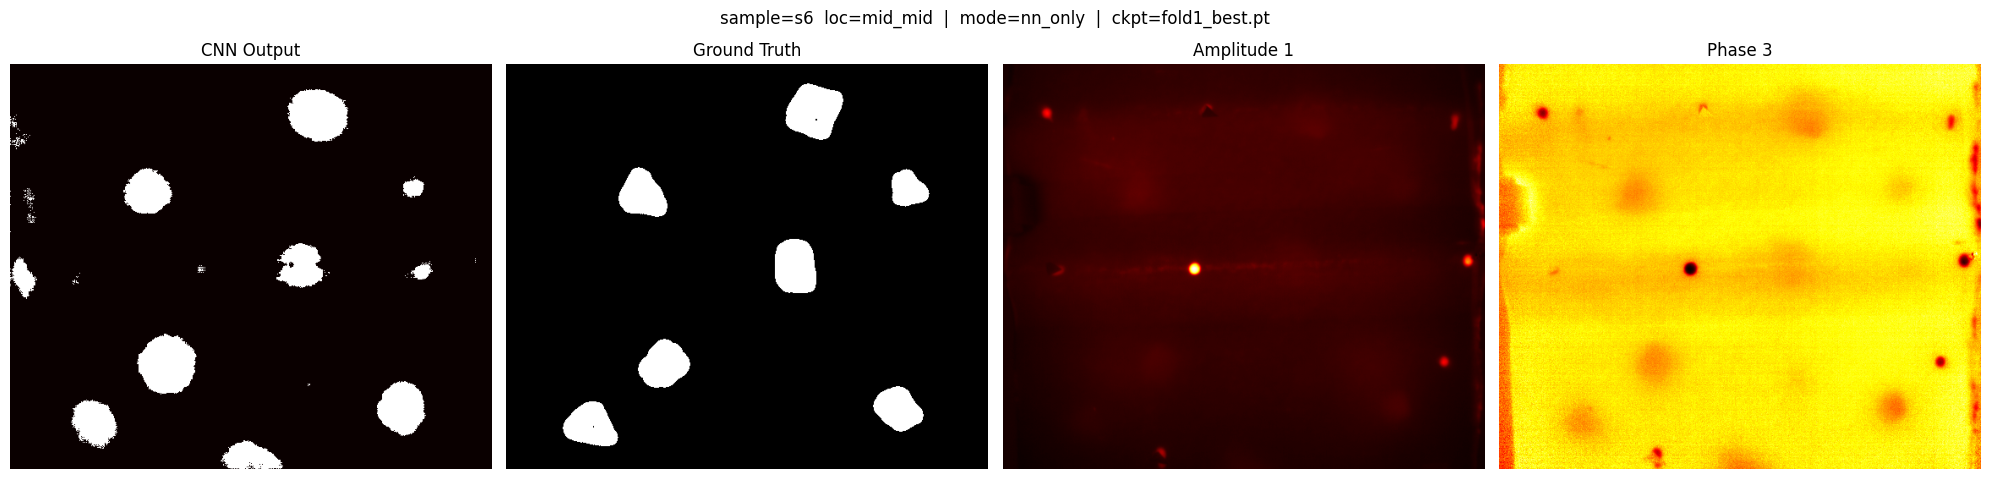

In [7]:
import matplotlib.pyplot as plt
#from NNsTorch.HybridTrainV2.hybrid_utils import HybridPatchDataset
from NNsTorchV2.HybridTrainV2.components.hybrid_utils_V2 import HybridPatchDataset
# ── Checkpoint ────────────────────────────────────────────────────────────────
FOLD_TO_CHECK = 1
thr = 0.55
#Manual: set path explicitly (works without manager)
# CKPT_DIR  = '/home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/checkpoints/cnn_skip/20260311-113040'
# CKPT_FILE = f'fold{FOLD_TO_CHECK}_best.pt'

# Auto (requires manager): uncomment to use
CKPT_DIR  = manager.ckpt_dir
CKPT_FILE = f'fold{FOLD_TO_CHECK}_best.pt'

ckpt_path = os.path.join(CKPT_DIR, CKPT_FILE)
#Converter for pipeline2:
_LOCS_6 = [
    'bottom_left',   # 0                                                                                                                                                   
    'bottom_right',  # 1                                                                                                                                                   
    'mid_left',      # 2
    'mid_right',     # 3                                                                                                                                                   
    'top_left',      # 4                                                                                                                                                 
    'top_right',     # 5
]

_LOCS_9 = [
    'bottom_left',   # 0
    'bottom_mid',    # 1
    'bottom_right',  # 2
    'mid_left',      # 3
    'mid_mid',       # 4
    'mid_right',     # 5
    'top_left',      # 6
    'top_mid',       # 7
    'top_right',     # 8
]

_6LOC_SAMPLES = {'s0', 's4'}

def convert_samples(samples: list) -> list:
    """Convert [(sample_name, loc_idx), ...] to [(sample_name, loc_name), ...]."""
    result = []
    for s, idx in samples:
        locs = _LOCS_6 if s in _6LOC_SAMPLES else _LOCS_9
        result.append((s, locs[idx]))
    return result
# ── Pick samples: (sample_name, location_idx) ─────────────────────────────────
SAMPLES_TO_CHECK = [
    ('s1', 1),
    ('s1', 4),
    # ('s3', 1),
    # ('s3', 5),-skip training as it has a small defects and setup has physical limitations
    ('s5', 2),
    ('s5', 4),
    ('s6', 2),
    ('s6', 4),
]
# SAMPLES_TO_CHECK = [
#     ('s0', 1),
#     ('s0', 3),
#     ('s0', 5),
#     ('s2', 1),
#     ('s2', 8),
#     ('s2', 5),
#     ('s4', 2),
#     ('s4', 5),
# ]
#For pipeline 2:
SAMPLES_TO_CHECK = convert_samples(SAMPLES_TO_CHECK)
# Reload best model from checkpoint
ckpt_model = model_fn().to(device)
ckpt_model.load_state_dict(
    torch.load(ckpt_path, map_location=device)['model_state_dict'])
ckpt_model.eval()

for sample in SAMPLES_TO_CHECK:
    # Always use patch_mode='full' for visualization — returns the complete image
    # regardless of what patch_mode was used during training
    check_ds = HybridPatchDataset(
        sample_indices = [sample],
        xgb_model      = manager.xgb_global,
        load_path      = manager.load_path,
        power_mode     = manager.power_mode,
        patch_size     = manager.patch_size,
        augment        = False,
        mask_type      = manager.mask_type,
        ppt_phases     = manager.ppt_phases,
        ppt_amps       = manager.ppt_amps,
        invert_mask    = manager.invert_mask,
        apply_jitter   = False,
        patch_mode     = 'full',
        data_regime    = manager.data_regime,
        min_mask_area  = 1300,  # Filter out samples with very small masks for clearer visualization
    )
    data_t, xgb_t, mask_t = check_ds[0]

    with torch.no_grad():
        if MODE == 'prob_only':
            inp = xgb_t.unsqueeze(0).to(device)
        elif MODE == 'prob_feat':
            inp = torch.cat([data_t, xgb_t], dim=0).unsqueeze(0).to(device)
        else:  # parallel / nn_only
            inp = data_t.unsqueeze(0).to(device)
        cnn_prob = torch.sigmoid(ckpt_model(inp)).squeeze().cpu().numpy()>thr

    xgb_np  = xgb_t.squeeze().numpy()
    mask_np = mask_t.numpy()
    from NNsTorchV2.core.data_discovery_V2 import discover_data_files_for_location
    import h5py

    fi = discover_data_files_for_location(
        manager.load_path, manager.power_mode, *sample,
        mask_type=manager.mask_type, data_regime=manager.data_regime,
    )
    with h5py.File(fi['features_h5'], 'r') as f:
        b = fi['base_key']
        amp1_np = f[f'{b}/PPT/a=0_width=280/Amp/component=1/data'][...].astype('float32')
        ppt3_np = f[f'{b}/PPT/a=0_width=280/Phase/component=3/data'][...].astype('float32')

    if MODE == 'parallel':
        combined = (cnn_prob + xgb_np) / 2
        titles = ['XGB Prob', 'CNN Prob', 'Combined', 'Ground Truth']
        imgs   = [xgb_np, cnn_prob, combined, mask_np]
        cmaps  = ['hot', 'hot', 'hot', 'gray']
    elif MODE == 'nn_only':
        titles = ['CNN Output', 'Ground Truth', 'Amplitude 1', 'Phase 3']
        imgs   = [cnn_prob, mask_np,amp1_np,ppt3_np]
        cmaps  = ['hot', 'gray', 'hot', 'hot']
    else:  # prob_only / prob_feat
        titles = ['XGB Prob', 'CNN Output', 'Ground Truth']
        imgs   = [xgb_np, cnn_prob, mask_np]
        cmaps  = ['hot', 'hot', 'gray']

    fig, axes = plt.subplots(1, len(imgs), figsize=(5 * len(imgs), 5))
    for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
        ax.imshow(img, cmap=cmap); ax.set_title(title); ax.axis('off')
    plt.suptitle(f"sample={sample[0]}  loc={sample[1]}  |  mode={MODE}  |  ckpt={CKPT_FILE}")
    plt.tight_layout(); plt.show()